In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv(r"C:\Users\USER\customer-churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check column names and data types
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("\nUnique values in Churn:", df['Churn'].unique())
print("Unique values in TotalCharges sample:", df['TotalCharges'].unique()[:10])


Unique values in Churn: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in TotalCharges sample: <ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95']
Length: 10, dtype: str


In [7]:
# 1. Convert TotalCharges to numeric (some values are empty spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many became NaN after conversion
print("NaN in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

NaN in TotalCharges after conversion: 11


In [8]:
# Drop the 11 rows with NaN TotalCharges (only 11 out of 7043 — safe to drop)
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Convert Churn to binary 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Drop customerID — not useful for ML
df.drop('customerID', axis=1, inplace=True)

# Verify
print("Shape after cleaning:", df.shape)
print("Churn value counts:\n", df['Churn'].value_counts())

Shape after cleaning: (7032, 20)
Churn value counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64


## Exploratory Data Analysis:

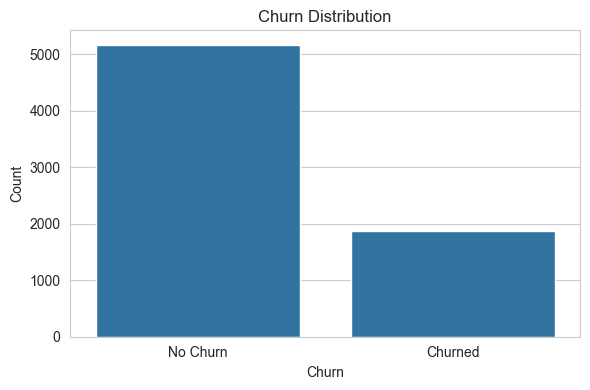

In [11]:
# Churn distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xticks([0,1], ['No Churn', 'Churned'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'C:\Users\USER\customer-churn-prediction/data/churn_distribution.png')
plt.show()

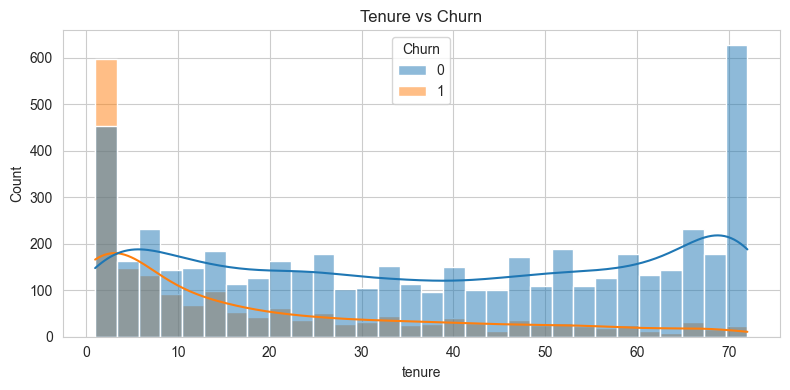

In [13]:
# Tenure vs Churn
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure vs Churn')
plt.tight_layout()
plt.savefig(r'C:\Users\USER\customer-churn-prediction/data/tenure_vs_churn.png')
plt.show()

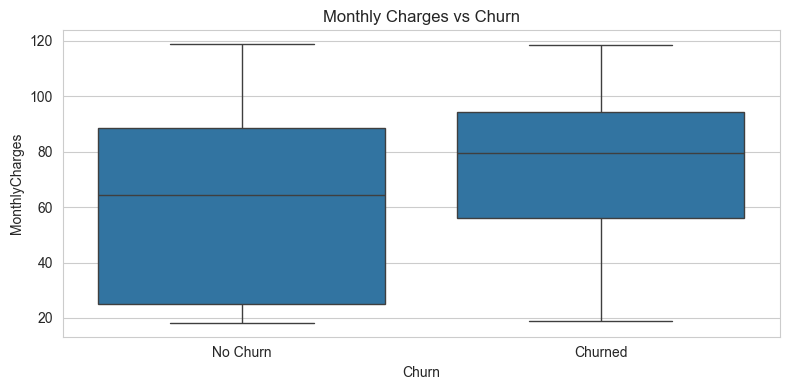

In [14]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xticks([0,1], ['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig(r'C:\Users\USER\customer-churn-prediction/data/monthly_charges_vs_churn.png')
plt.show()

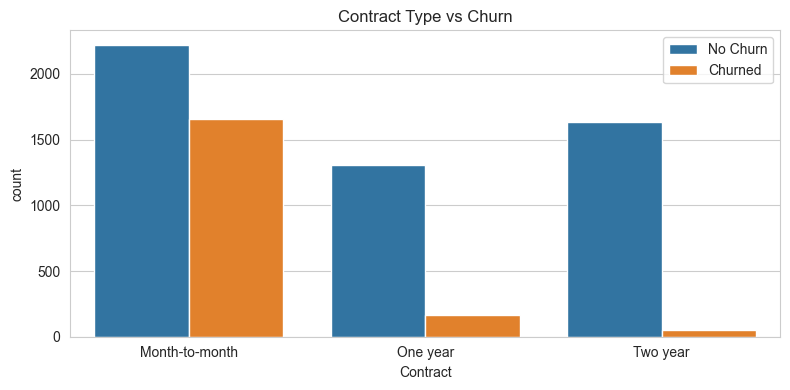

In [15]:
# Contract type vs Churn
plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig(r'C:\Users\USER\customer-churn-prediction/data/contract_vs_churn.png')
plt.show()

In [16]:
# Churn rate by contract type
print(df.groupby('Contract')['Churn'].mean().round(2) * 100)

Contract
Month-to-month    43.0
One year          11.0
Two year           3.0
Name: Churn, dtype: float64
